In [1]:
import seaborn as sns
import pandas as pd

# The one and only raw Titanic dataset load
df = sns.load_dataset("titanic")

# Required offline fallback
df.to_csv("titanic.csv", index=False)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (891, 15)


In [2]:
print("===== DATASET INFO =====")
df.info()

print("\n===== DESCRIPTIVE STATISTICS =====")
display(df.describe(include="all").T)

print("\n===== DATASET SHAPE =====")
print(df.shape)

print("\n===== MISSING VALUE PERCENTAGES =====")

missing_percent = (
    df.isnull()
      .mean()
      .mul(100)
      .loc[lambda x: x > 0]
      .sort_values(ascending=False)
)

display(
    missing_percent.to_frame(
        name="missing_percentage"
    )
)

===== DATASET INFO =====
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB

===== DESCRIPTIVE STATISTICS =====


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
sibsp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292
embarked,889,3,S,644,NaN,NaN,NaN,NaN,NaN,NaN,NaN
class,891,3,Third,491,NaN,NaN,NaN,NaN,NaN,NaN,NaN
who,891,3,man,537,NaN,NaN,NaN,NaN,NaN,NaN,NaN



===== DATASET SHAPE =====
(891, 15)

===== MISSING VALUE PERCENTAGES =====


,missing_percentage
deck,77.216611
age,19.865320
embarked,0.224467
embark_town,0.224467


In [3]:
# ==========================================
# MISSING-VALUE HANDLING
# ==========================================

# Record the measured percentages for documentation.
missing_report = (
    df.isnull()
      .mean()
      .mul(100)
      .loc[lambda x: x > 0]
)

print("Missing-value percentages before cleaning:")
display(
    missing_report.to_frame(
        name="missing_percentage"
    )
)

# 1. deck: 77.2166% missing
# Drop because the missingness is too high for reliable imputation.
df = df.drop(columns=["deck"])

# 2. embarked: 0.2245% missing
# 3. embark_town: 0.2245% missing
# Both are below 5%, so drop the affected rows.
df = df.dropna(
    subset=["embarked", "embark_town"]
)

# 4. age: 19.8653% missing
# Between 5% and 30%, so use median imputation.
age_median = df["age"].median()

df["age"] = df["age"].fillna(age_median)

print("\nMissing values after cleaning:")
display(
    df.isnull()
      .sum()
      .loc[lambda x: x > 0]
)

print("\nCleaned dataset shape:")
print(df.shape)

print("\nAge median used for imputation:")
print(age_median)

Missing-value percentages before cleaning:


,missing_percentage
age,19.865320
embarked,0.224467
deck,77.216611
embark_town,0.224467



Missing values after cleaning:


Series([], dtype: int64)


Cleaned dataset shape:
(889, 14)

Age median used for imputation:
28.0


In [7]:
# Save the final cleaned dataset for the modeling pipeline.
df.to_csv("titanic.csv", index=False)

print("Cleaned dataset saved successfully.")
print("Shape:", df.shape)

Cleaned dataset saved successfully.
Shape: (889, 14)


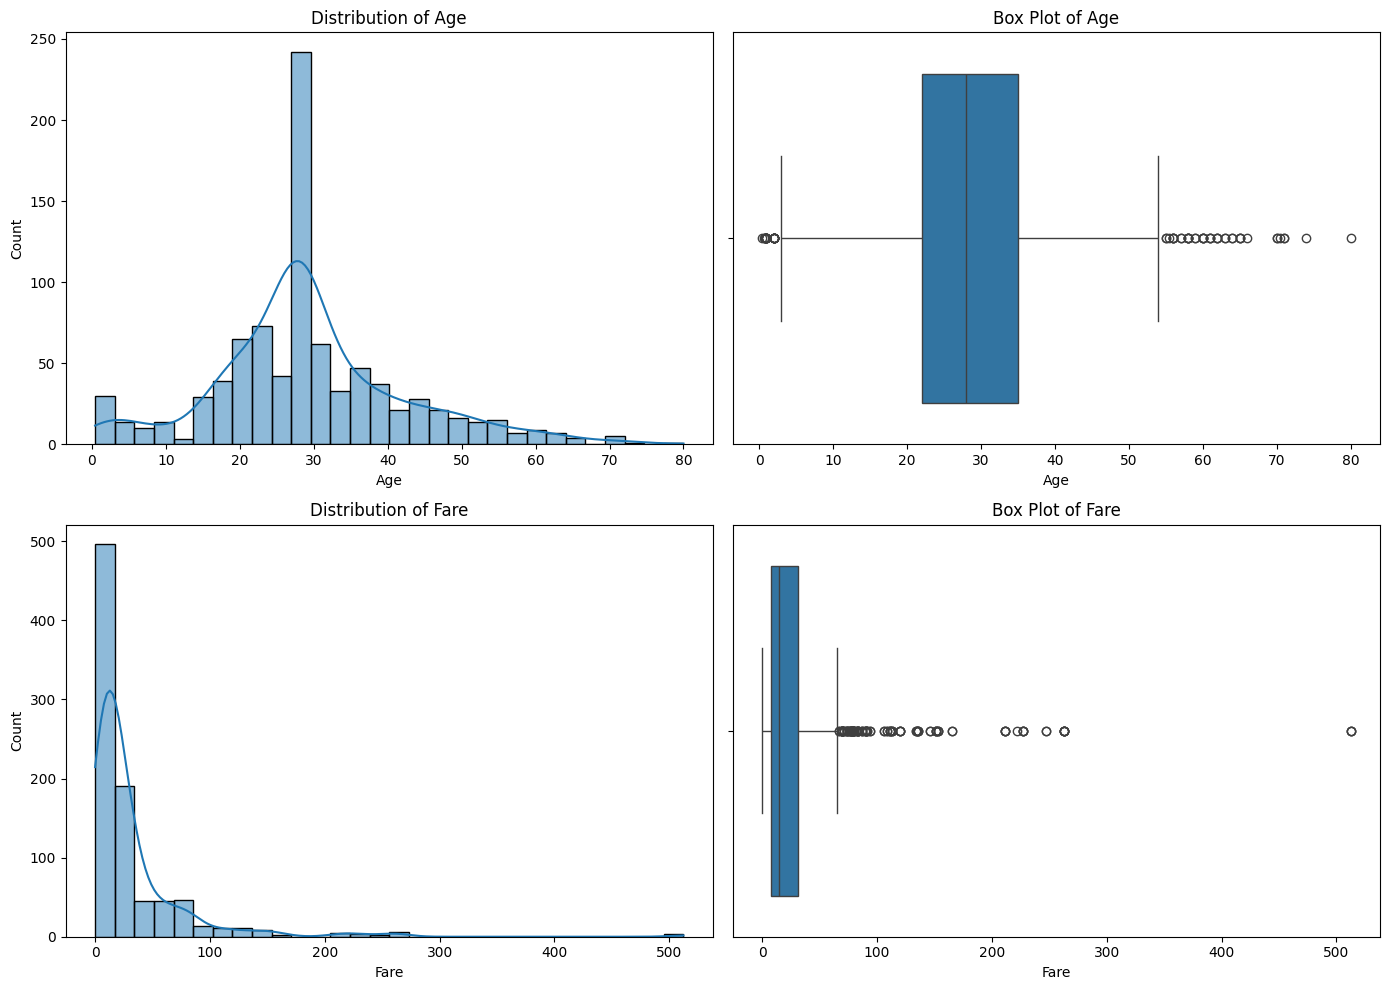

===== AGE IQR ANALYSIS =====
{'Q1': np.float64(22.0), 'Q3': np.float64(35.0), 'IQR': np.float64(13.0), 'lower_bound': np.float64(2.5), 'upper_bound': np.float64(54.5), 'outlier_count': 65}

===== FARE IQR ANALYSIS =====
{'Q1': np.float64(7.8958), 'Q3': np.float64(31.0), 'IQR': np.float64(23.1042), 'lower_bound': np.float64(-26.7605), 'upper_bound': np.float64(65.6563), 'outlier_count': 114}

===== FARE CENTRAL TENDENCY =====
Mean: 32.09668087739032
Median: 14.4542
Mode: 8.05

Fare distribution: right-skewed


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


# ==========================================
# UNIVARIATE ANALYSIS
# ==========================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age histogram
sns.histplot(
    df["age"],
    bins=30,
    kde=True,
    ax=axes[0, 0]
)
axes[0, 0].set_title("Distribution of Age")
axes[0, 0].set_xlabel("Age")

# Age box plot
sns.boxplot(
    x=df["age"],
    ax=axes[0, 1]
)
axes[0, 1].set_title("Box Plot of Age")
axes[0, 1].set_xlabel("Age")

# Fare histogram
sns.histplot(
    df["fare"],
    bins=30,
    kde=True,
    ax=axes[1, 0]
)
axes[1, 0].set_title("Distribution of Fare")
axes[1, 0].set_xlabel("Fare")

# Fare box plot
sns.boxplot(
    x=df["fare"],
    ax=axes[1, 1]
)
axes[1, 1].set_title("Box Plot of Fare")
axes[1, 1].set_xlabel("Fare")

plt.tight_layout()
plt.show()


# ==========================================
# IQR OUTLIER ANALYSIS
# ==========================================

def iqr_outlier_count(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = series[
        (series < lower_bound) |
        (series > upper_bound)
    ]

    return {
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": len(outliers)
    }


age_outliers = iqr_outlier_count(df["age"])
fare_outliers = iqr_outlier_count(df["fare"])


print("===== AGE IQR ANALYSIS =====")
print(age_outliers)

print("\n===== FARE IQR ANALYSIS =====")
print(fare_outliers)


# ==========================================
# FARE CENTRAL TENDENCY
# ==========================================

fare_mean = df["fare"].mean()
fare_median = df["fare"].median()
fare_mode = df["fare"].mode().iloc[0]

print("\n===== FARE CENTRAL TENDENCY =====")
print("Mean:", fare_mean)
print("Median:", fare_median)
print("Mode:", fare_mode)


# ==========================================
# FARE SKEWNESS INTERPRETATION
# ==========================================

if fare_mean > fare_median > fare_mode:
    skew_interpretation = "right-skewed"
elif fare_mean < fare_median < fare_mode:
    skew_interpretation = "left-skewed"
else:
    skew_interpretation = "not clearly classified by mean/median/mode ordering"

print(
    "\nFare distribution:",
    skew_interpretation
)

===== SURVIVAL RATE BY SEX =====


,survival_rate_percent
sex,
female,74.04
male,18.89



===== SURVIVAL RATE BY PCLASS =====


,survival_rate_percent
pclass,
1,62.62
2,47.28
3,24.24



===== SURVIVAL RATE BY SEX + PCLASS =====


,sex,pclass,survival_rate_percent,passengers
0,female,1,96.74,92
1,female,2,92.11,76
2,female,3,50.00,144
3,male,1,36.89,122
4,male,2,15.74,108
5,male,3,13.54,347



Female passengers in 1st OR 2nd class: 168

===== CORRELATION MATRIX =====


,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.335549,-0.069822,-0.034040,0.083151,0.255290
pclass,-0.335549,1.000000,-0.336512,0.081656,0.016824,-0.548193
age,-0.069822,-0.336512,1.000000,-0.232543,-0.171485,0.093707
sibsp,-0.034040,0.081656,-0.232543,1.000000,0.414542,0.160887
parch,0.083151,0.016824,-0.171485,0.414542,1.000000,0.217532
fare,0.255290,-0.548193,0.093707,0.160887,0.217532,1.000000


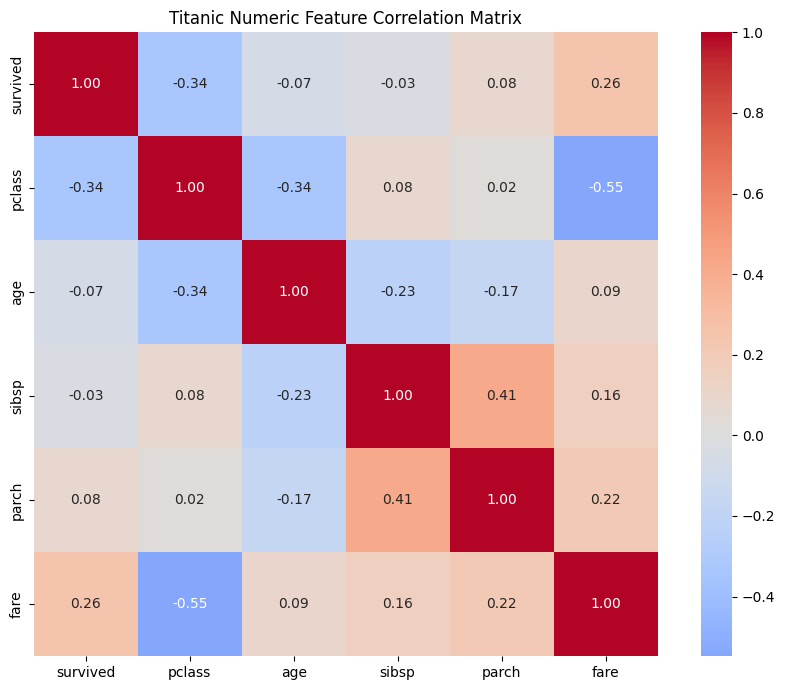


===== TWO STRONGEST CORRELATIONS =====


,feature_1,feature_2,correlation,absolute_correlation
0,pclass,fare,-0.548193,0.548193
1,sibsp,parch,0.414542,0.414542


In [5]:
# ==========================================
# BIVARIATE ANALYSIS
# ==========================================

print("===== SURVIVAL RATE BY SEX =====")

survival_by_sex = (
    df.groupby("sex")["survived"]
      .mean()
      .mul(100)
      .round(2)
)

display(
    survival_by_sex.to_frame(
        "survival_rate_percent"
    )
)


print("\n===== SURVIVAL RATE BY PCLASS =====")

survival_by_pclass = (
    df.groupby("pclass")["survived"]
      .mean()
      .mul(100)
      .round(2)
)

display(
    survival_by_pclass.to_frame(
        "survival_rate_percent"
    )
)


# ==========================================
# SEX + PCLASS USING BOOLEAN MASKING
# ==========================================

print("\n===== SURVIVAL RATE BY SEX + PCLASS =====")

sex_pclass_results = []

for sex in ["female", "male"]:

    for pclass in [1, 2, 3]:

        mask = (
            (df["sex"] == sex)
            & (df["pclass"] == pclass)
        )

        group = df.loc[mask]

        survival_rate = (
            group["survived"].mean() * 100
        )

        sex_pclass_results.append(
            {
                "sex": sex,
                "pclass": pclass,
                "survival_rate_percent": round(
                    survival_rate,
                    2
                ),
                "passengers": len(group)
            }
        )

sex_pclass_df = pd.DataFrame(
    sex_pclass_results
)

display(sex_pclass_df)


# ==========================================
# EXPLICIT BOOLEAN MASKING EXAMPLES
# ==========================================

female_first_or_second = df[
    (df["sex"] == "female")
    &
    (
        (df["pclass"] == 1)
        |
        (df["pclass"] == 2)
    )
]

print(
    "\nFemale passengers in 1st OR 2nd class:",
    len(female_first_or_second)
)


# ==========================================
# EXACT SIX-COLUMN CORRELATION MATRIX
# ==========================================

correlation_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

correlation_matrix = df[
    correlation_columns
].corr()

print("\n===== CORRELATION MATRIX =====")

display(correlation_matrix)


# ==========================================
# CORRELATION HEATMAP
# ==========================================

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title(
    "Titanic Numeric Feature Correlation Matrix"
)

plt.tight_layout()
plt.show()


# ==========================================
# FIND TWO STRONGEST CORRELATIONS
# ==========================================

correlation_pairs = []

for i in range(
    len(correlation_columns)
):

    for j in range(
        i + 1,
        len(correlation_columns)
    ):

        feature_1 = correlation_columns[i]
        feature_2 = correlation_columns[j]

        correlation_value = (
            correlation_matrix.loc[
                feature_1,
                feature_2
            ]
        )

        correlation_pairs.append(
            {
                "feature_1": feature_1,
                "feature_2": feature_2,
                "correlation": correlation_value,
                "absolute_correlation": abs(
                    correlation_value
                )
            }
        )

strongest_correlations = (
    pd.DataFrame(correlation_pairs)
      .sort_values(
          "absolute_correlation",
          ascending=False
      )
      .head(2)
      .reset_index(drop=True)
)

print(
    "\n===== TWO STRONGEST CORRELATIONS ====="
)

display(strongest_correlations)

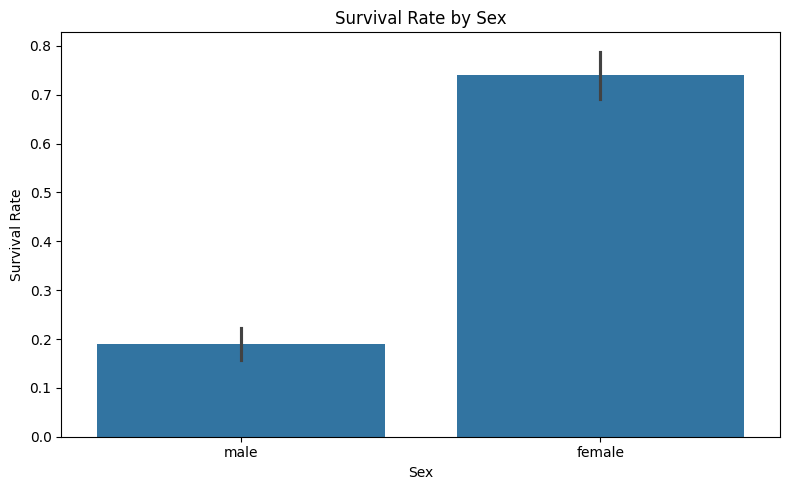

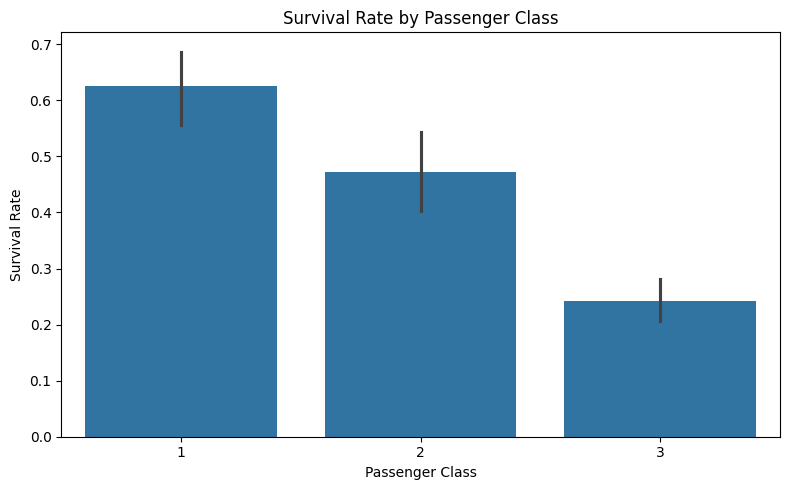

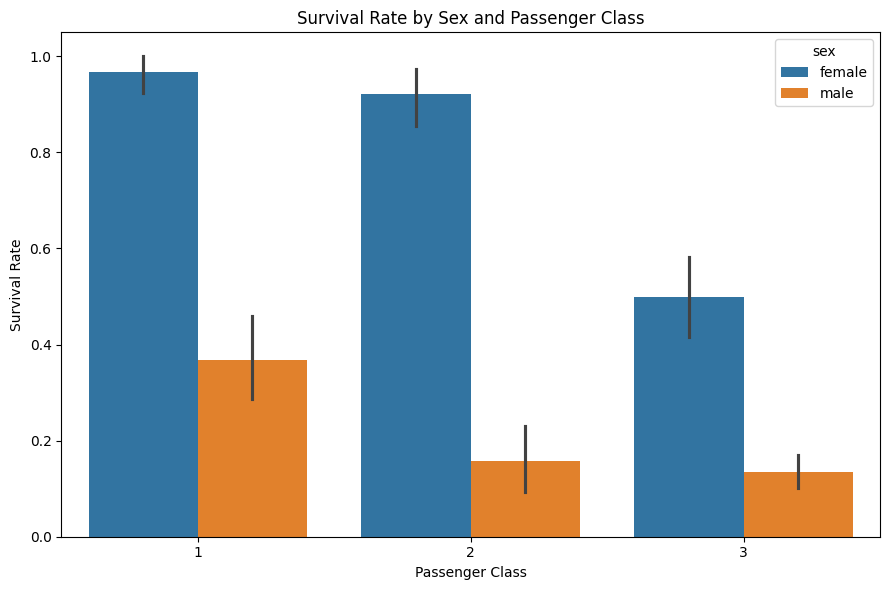

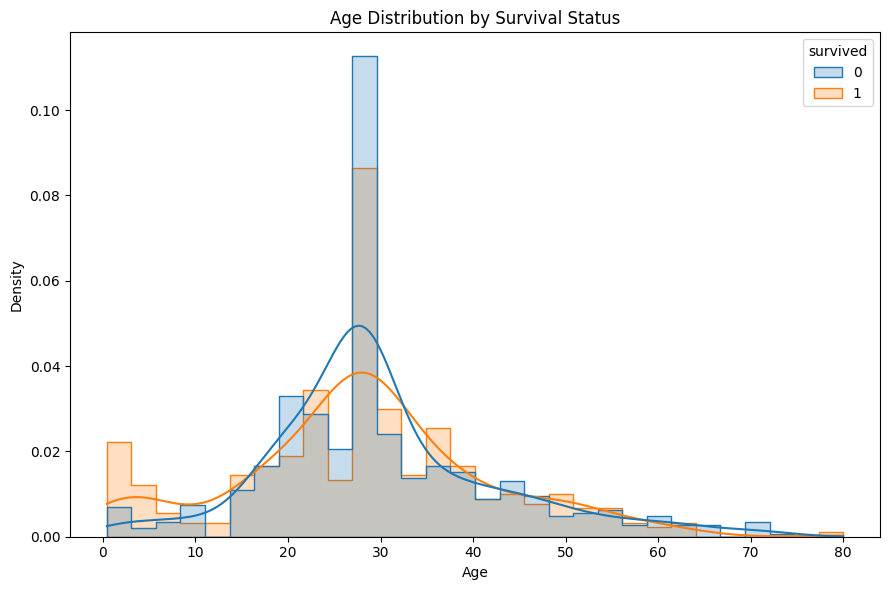

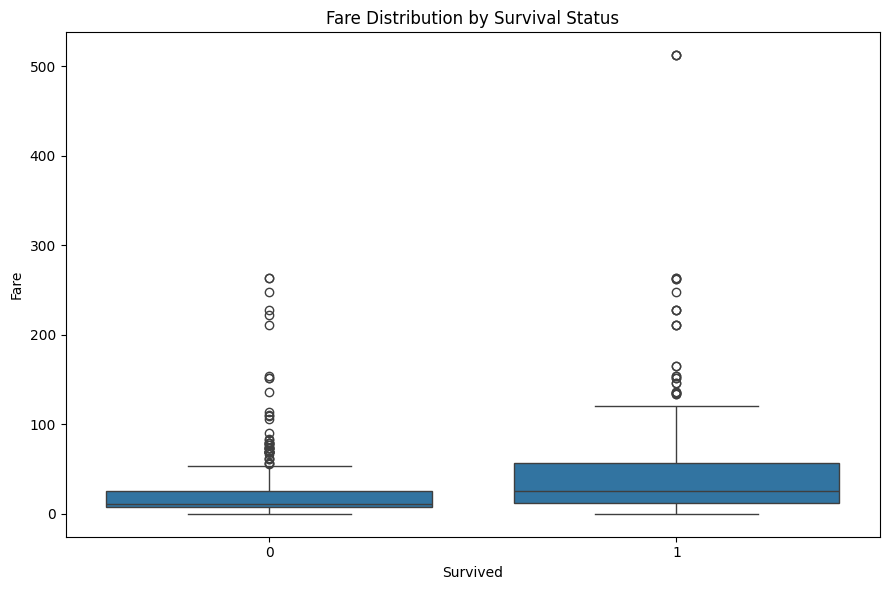

In [6]:
# ==========================================
# MULTIVARIATE DATA STORY
# ==========================================

# Chart 1: Survival by sex
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="sex",
    y="survived"
)

plt.title("Survival Rate by Sex")
plt.ylabel("Survival Rate")
plt.xlabel("Sex")

plt.tight_layout()
plt.show()


# Chart 2: Survival by passenger class
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="pclass",
    y="survived"
)

plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Rate")
plt.xlabel("Passenger Class")

plt.tight_layout()
plt.show()


# Chart 3: Survival by sex and passenger class
plt.figure(figsize=(9, 6))

sns.barplot(
    data=df,
    x="pclass",
    y="survived",
    hue="sex"
)

plt.title(
    "Survival Rate by Sex and Passenger Class"
)

plt.ylabel("Survival Rate")
plt.xlabel("Passenger Class")

plt.tight_layout()
plt.show()


# Chart 4: Age distribution by survival
plt.figure(figsize=(9, 6))

sns.histplot(
    data=df,
    x="age",
    hue="survived",
    bins=30,
    kde=True,
    element="step",
    stat="density",
    common_norm=False
)

plt.title(
    "Age Distribution by Survival Status"
)

plt.xlabel("Age")
plt.ylabel("Density")

plt.tight_layout()
plt.show()


# Chart 5: Fare distribution by survival
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="survived",
    y="fare"
)

plt.title(
    "Fare Distribution by Survival Status"
)

plt.xlabel("Survived")
plt.ylabel("Fare")

plt.tight_layout()
plt.show()

## Multivariate Data Story

The visualizations show that survival was strongly associated with passenger demographics and socioeconomic position.

The survival-by-sex chart shows a substantial difference between female and male passengers, with female passengers having a much higher survival rate than male passengers.

Passenger class also shows a clear relationship with survival. First-class passengers had the highest survival rate, followed by second-class passengers, while third-class passengers had the lowest survival rate.

The combined sex-and-class visualization provides a stronger multivariate view. Female passengers in first and second class had particularly high survival rates, while male passengers in second and third class had substantially lower survival rates. This demonstrates that passenger class and sex jointly provide important information about survival outcomes.

The age distribution shows how survivor and non-survivor populations were distributed across ages, while the fare comparison shows that passengers with higher fares tended to have different survival outcomes from passengers paying lower fares.

Overall, the visualizations suggest that survival was not driven by a single variable. Sex and passenger class provide especially strong segmentation, while age and fare add further information about differences between survivors and non-survivors.